
# Evaluate the performance of a classifier with Confusion Matrix

Example of confusion matrix usage to evaluate the quality
of the output of a classifier on the iris data set. The
diagonal elements represent the number of points for which
the predicted label is equal to the true label, while
off-diagonal elements are those that are mislabeled by the
classifier. The higher the diagonal values of the confusion
matrix the better, indicating many correct predictions.

The figures show the confusion matrix with and without
normalization by class support size (number of elements
in each class). This kind of normalization can be
interesting in case of class imbalance to have a more
visual interpretation of which class is being misclassified.

Here the results are not as good as they could be as our
choice for the regularization parameter C was not the best.
In real life applications this parameter is usually chosen
using `grid_search`.


Confusion matrix, without normalization
[[13  0  0]
 [ 0 10  6]
 [ 0  0  9]]
Normalized confusion matrix
[[1.   0.   0.  ]
 [0.   0.62 0.38]
 [0.   0.   1.  ]]


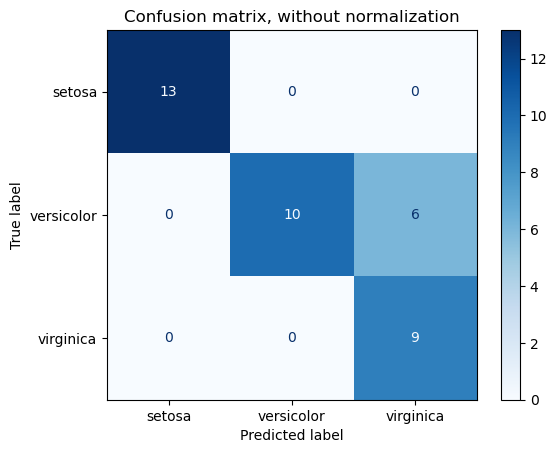

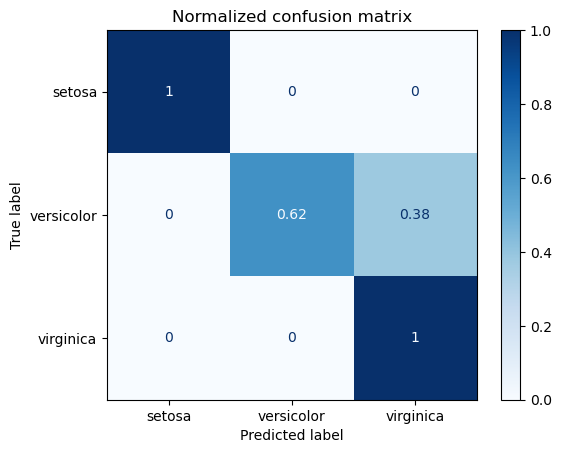

In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# import some data to play with
iris = datasets.load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Run classifier, using a model that is too regularized (C too low) to see
# the impact on the results
classifier = svm.SVC(kernel="linear", C=0.01).fit(X_train, y_train)

np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        classifier,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

## Binary Classification

For binary problems, :func:`sklearn.metrics.confusion_matrix` has the `ravel` method
we can use get counts of true negatives, false positives, false negatives and
true positives.

To obtain true negatives, false positives, false negatives and true
positives counts at different thresholds, one can use
:func:`sklearn.metrics.confusion_matrix_at_thresholds`.
This is fundamental for binary classification
metrics like :func:`~sklearn.metrics.roc_auc_score` and
:func:`~sklearn.metrics.det_curve`.



In [2]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix_at_thresholds

X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=20,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

classifier = svm.SVC(kernel="linear", C=0.01, probability=True)
classifier.fit(X_train, y_train)

y_score = classifier.predict_proba(X_test)[:, 1]

tns, fps, fns, tps, threshold = confusion_matrix_at_thresholds(y_test, y_score)

# Plot TNs, FPs, FNs and TPs vs Thresholds
plt.figure(figsize=(10, 6))

plt.plot(threshold, tns, label="True Negatives (TNs)")
plt.plot(threshold, fps, label="False Positives (FPs)")
plt.plot(threshold, fns, label="False Negatives (FNs)")
plt.plot(threshold, tps, label="True Positives (TPs)")
plt.xlabel("Thresholds")
plt.ylabel("Count")
plt.title("TNs, FPs, FNs and TPs vs Thresholds")
plt.legend()
plt.grid()

plt.show()

ImportError: cannot import name 'confusion_matrix_at_thresholds' from 'sklearn.metrics' (c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\__init__.py)